In [ ]:
# =====================================================# CALCULO: Distancia minima Tierra-Apophis (REBOUND)# =====================================================import numpy as npimport matplotlib.pyplot as pltfrom astropy.time import Timei_tierra = 1i_apophis = 2r_tierra_rb = rs_rb_helio[i_tierra]r_apophis_rb = rs_rb_helio[i_apophis]delta_r = r_apophis_rb - r_tierra_rbdist_ta_ua = np.linalg.norm(delta_r, axis=1)dist_ta_km = dist_ta_ua * U_L / 1e3idx_min = np.argmin(dist_ta_km)d_min_km = dist_ta_km[idx_min]d_min_ua = dist_ta_ua[idx_min]t_dias_min = t_dias_rb[idx_min]fecha_min = Time(fecha_inicio).to_datetime() + np.timedelta64(int(t_dias_min), 'D')fecha_referencia = Time('2029-04-13').to_datetime()delta_dias_ref = (fecha_min - fecha_referencia).daysprint('='*60)print('DISTANCIA MINIMA TIERRA-APOPHIS (Simulacion REBOUND)')print('='*60)print(f'Fecha del acercamiento: {fecha_min:%Y-%m-%d}')print(f'Distancia minima: {d_min_km:>12,.1f} km')print(f'Distancia minima: {d_min_ua:>12.6f} UA')print(f'Fecha referencia (2029-04-13): {fecha_referencia:%Y-%m-%d}')print(f'Diferencia: {delta_dias_ref:>+4d} dias')print('='*60)ancho = 150i_start = max(0, idx_min - ancho)i_end = min(len(t_dias_rb), idx_min + ancho + 1)fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))ax1.plot(anios_rb[i_start:i_end], dist_ta_km[i_start:i_end], 'b-', lw=2)ax1.scatter([anios_rb[idx_min]], [d_min_km], color='red', s=100, zorder=5)ax1.axvline(anios_rb[idx_min], color='red', linestyle='--', alpha=0.5)ax1.set_xlabel('Año calendario')ax1.set_ylabel('Distancia (km)')ax1.set_title('Acercamiento Tierra-Apophis (zoom 300 dias)')ax1.grid(True, alpha=0.3)r_tierra_zoom = r_tierra_rb[i_start:i_end] / U_Lr_apophis_zoom = r_apophis_rb[i_start:i_end] / U_Lax2.plot(r_tierra_zoom[:, 0], r_tierra_zoom[:, 1], 'b-', lw=2, label='Tierra')ax2.plot(r_apophis_zoom[:, 0], r_apophis_zoom[:, 1], 'r-', lw=2, label='Apophis')ax2.scatter([r_tierra_zoom[idx_min - i_start, 0]], [r_tierra_zoom[idx_min - i_start, 1]], color='blue', s=100, marker='o', zorder=5)ax2.scatter([r_apophis_zoom[idx_min - i_start, 0]], [r_apophis_zoom[idx_min - i_start, 1]], color='red', s=100, marker='o', zorder=5)ax2.set_xlabel('X (UA)')ax2.set_ylabel('Y (UA)')ax2.set_title('Orbitas heliocentricas (zoom local)')ax2.grid(True, alpha=0.3)ax2.legend()ax2.axis('equal')plt.tight_layout()plt.show()fig, ax = plt.subplots(figsize=(12, 5))ax.plot(anios_rb, dist_ta_km, 'k-', lw=1, alpha=0.7)ax.scatter([anios_rb[idx_min]], [d_min_km], color='red', s=150, zorder=5, marker='*')ax.axhline(10e6, color='gray', linestyle=':', alpha=0.5)ax.axvline(anios_rb[idx_min], color='red', linestyle='--', alpha=0.3)ax.set_xlabel('Año calendario')ax.set_ylabel('Distancia (km)')ax.set_title('Distancia Tierra-Apophis (20 anos)')ax.grid(True, alpha=0.3)ax.legend(['Distancia REBOUND', 'Minimo'], loc='upper right')ax.set_ylim([0, max(dist_ta_km) * 1.05])plt.tight_layout()plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pymcel as pc
from plotly import graph_objects as go
import rebound as rb
from astropy.time import Time

: 

In [ ]:
# Se hara un sistema con el Sol, la tierra, Apophis, Jupiter. y se hara una simulacion de 20 aÃƒÆ’Ã‚Â±os para ver la trayectoria de Apophis. Se hara una simulacion con el metodo de Euler y otra con el metodo de Runge-Kutta de orden 4 para comparar los resultados. Se hara una grafica de la trayectoria de Apophis en el plano xy y otra grafica de la distancia entre Apophis y la Tierra en funcion del tiempo.
fecha_inicio = '2026-3-22'
fecha_final = '2046-3-22'
tabla_sol,jd_sol, X_sol = pc.consulta_horizons('10',location='@SSB',epochs= fecha_inicio)
tabla_tierra,jd_tierra, X_tierra = pc.consulta_horizons('399',location='@SSB',epochs= fecha_inicio)
tabla_apophis,jd_apophis, X_apophis = pc.consulta_horizons('99942',location='@SSB',epochs= fecha_inicio)
tabla_jupiter,jd_jupiter, X_jupiter = pc.consulta_horizons('599',location='@SSB',epochs= fecha_inicio)
# Se extraen las posiciones y velocidades de cada cuerpo
pos_sol = X_sol[0:3]
vel_sol = X_sol[3:6]
pos_tierra = X_tierra[0:3]
vel_tierra = X_tierra[3:6]
pos_apophis = X_apophis[0:3]
vel_apophis = X_apophis[3:6]
pos_jupiter = X_jupiter[0:3]
vel_jupiter = X_jupiter[3:6]

print('Posicion del Sol:', pos_sol)
print('Velocidad del Sol:', vel_sol)    
print('Posicion de la Tierra:', pos_tierra)
print('Velocidad de la Tierra:', vel_tierra)
print('Posicion de Apophis:', pos_apophis)
print('Velocidad de Apophis:', vel_apophis)
print('Posicion de Jupiter:', pos_jupiter)
print('Velocidad de Jupiter:', vel_jupiter)




Posicion del Sol: [-3.74082124e+08 -8.21077523e+08  1.80394185e+07]
Velocidad del Sol: [12.07660487  1.66469579 -0.24321337]
Posicion de la Tierra: [-1.49395136e+11 -3.45562165e+09  1.86670252e+07]
Velocidad de la Tierra: [ 6.26795448e+01 -2.99038132e+04  9.94953730e-01]
Posicion de Apophis: [ 2.52980785e+10  1.38445391e+11 -6.80774098e+09]
Velocidad de Apophis: [-28082.51741589  10931.64170382  -1248.02944168]
Posicion de Jupiter: [-3.38451934e+11  7.06530130e+11  4.64368237e+09]
Velocidad de Jupiter: [-11937.26386791  -5027.94005781    288.0081068 ]


In [ ]:
#definicion de constantes
G = 6.67430e-11 # Constante de gravitaciÃƒÆ’Ã‚Â³n universal en m^3 kg^-1 s^-2
M_sol = 1.989e30 # Masa del Sol en kg
M_tierra = 5.972e24 # Masa de la Tierra en kg
M_apophis = 2.7e10 # Masa de Apophis en kg
M_jupiter = 1.898e27 # Masa de Jupiter en kg

In [ ]:
# Definicion unidades canonicas
U_L = 1.496e11 # Unidad de longitud en metros (1 UA)
U_M = M_sol # Unidad de masa en kg (masa del Sol)
U_T = np.sqrt(U_L**3 / (G * U_M)) # Unidad de tiempo en segundos



In [ ]:
# creare el sistema
sistema = [
    dict(m=M_sol, r=pos_sol, v=vel_sol),
    dict(m=M_tierra, r=pos_tierra, v=vel_tierra),
    dict(m=M_apophis, r=pos_apophis, v=vel_apophis),
    dict(m=M_jupiter, r=pos_jupiter, v=vel_jupiter)
]

# crear el tiempo de simulacion con base en las fechas de inicio y final

tiempo_inicio = Time(fecha_inicio).jd
tiempo_final = Time(fecha_final).jd
tiempo_simulacion = tiempo_final - tiempo_inicio  # dias

# crear el numero de pasos usando dt = 1 dia
dt = 1.0  # dias
num_pasos = int(tiempo_simulacion / dt) + 1

# vector de tiempo en JD, en dias relativos y en anios calendario
t_jd = np.linspace(tiempo_inicio, tiempo_final, num_pasos)
t_dias = t_jd - tiempo_inicio
t_anios = t_dias / 365.25
anio_inicio = Time(fecha_inicio).decimalyear
anios_calendario = anio_inicio + t_anios

print(f"Tiempo simulacion: {tiempo_simulacion:.2f} dias")
print(f"Tiempo simulacion: {t_anios[-1]:.2f} anios")
print(f"Pasos: {num_pasos}")
print(f"dt efectivo en linspace: {t_jd[1] - t_jd[0]:.6f} dias")
t_jd

Tiempo simulacion: 7305.00 dias
Tiempo simulacion: 20.00 anios
Pasos: 7306
dt efectivo en linspace: 1.000000 dias


c:\Users\nando\Repositorio-git-Mcenica-celeste\mec-nica-celeste\Proyecto_celeste\mecanica_celeste\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


array([2461121.5, 2461122.5, 2461123.5, ..., 2468424.5, 2468425.5,
       2468426.5], shape=(7306,))

In [ ]:
rs, vs, rps, vps, constantes = pc.ncuerpos_solucion(sistema, t_jd)

# grafica 3D de trayectorias: rs tiene forma (N_cuerpos, N_tiempos, 3)
nombres = ['Sol', 'Tierra', 'Apophis', 'Jupiter']
fig = go.Figure()
for i, nombre in enumerate(nombres):
    fig.add_trace(
        go.Scatter3d(
            x=rs[i, :, 0],
            y=rs[i, :, 1],
            z=rs[i, :, 2],
            mode='lines',
            name=nombre,
        )
    )

fig.update_layout(
    title='Trayectorias de los cuerpos',
    scene=dict(
        xaxis_title='X (m)',
        yaxis_title='Y (m)',
        zaxis_title='Z (m)',
        aspectmode='data'
    ),
)
fig.show(renderer='browser')

c:\Users\nando\Repositorio-git-Mcenica-celeste\mec-nica-celeste\Proyecto_celeste\mecanica_celeste\Lib\site-packages\pymcel\__init__.py:1408: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  solucion=odeint(edm_ncuerpos_eficiente,Y0s,ts,args=(N,mus))
c:\Users\nando\Repositorio-git-Mcenica-celeste\mec-nica-celeste\Proyecto_celeste\mecanica_celeste\Lib\site-packages\pymcel\__init__.py:1441: RuntimeWarning: divide by zero encountered in divide
  U+=-0.5*mus[i]*mus[j]/rij


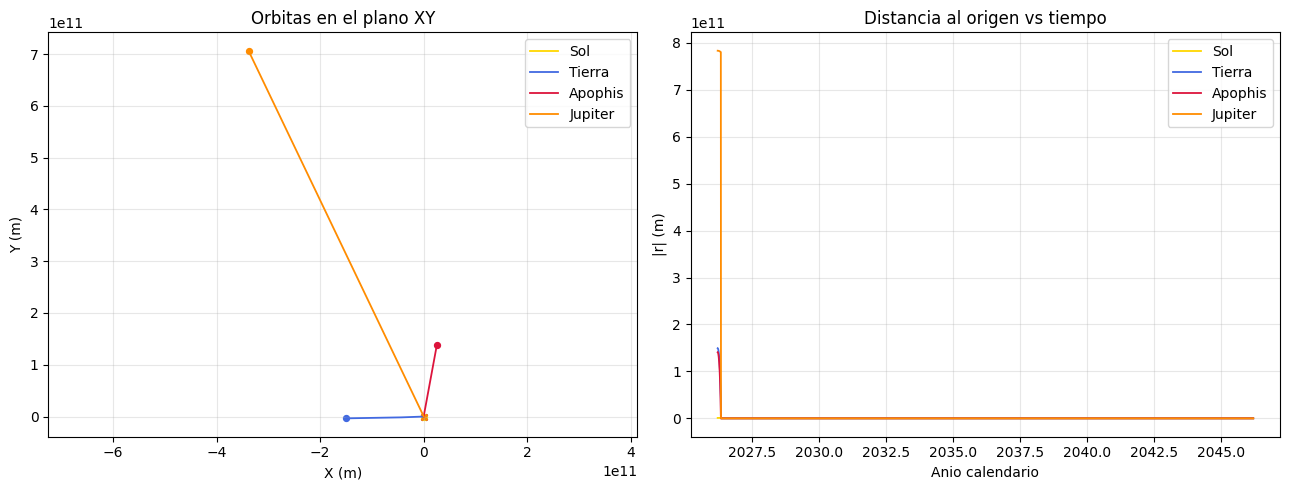

In [ ]:
# Orbitas con Matplotlib (plano XY) y evolucion radial en funcion del tiempo
nombres = ['Sol', 'Tierra', 'Apophis', 'Jupiter']
colores = ['gold', 'royalblue', 'crimson', 'darkorange']

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: orbitas XY
for i, nombre in enumerate(nombres):
    ax[0].plot(rs[i, :, 0], rs[i, :, 1], lw=1.3, color=colores[i], label=nombre)
    ax[0].scatter(rs[i, 0, 0], rs[i, 0, 1], color=colores[i], s=18, marker='o')  # inicio
    ax[0].scatter(rs[i, -1, 0], rs[i, -1, 1], color=colores[i], s=18, marker='x')  # final

ax[0].set_title('Orbitas en el plano XY')
ax[0].set_xlabel('X (m)')
ax[0].set_ylabel('Y (m)')
ax[0].axis('equal')
ax[0].grid(True, alpha=0.3)
ax[0].legend()

# Panel 2: distancia al origen en funcion del tiempo
for i, nombre in enumerate(nombres):
    r_mod = np.linalg.norm(rs[i, :, :], axis=1)
    ax[1].plot(anios_calendario, r_mod, lw=1.3, color=colores[i], label=nombre)

ax[1].set_title('Distancia al origen vs tiempo')
ax[1].set_xlabel('Anio calendario')
ax[1].set_ylabel('|r| (m)')
ax[1].grid(True, alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

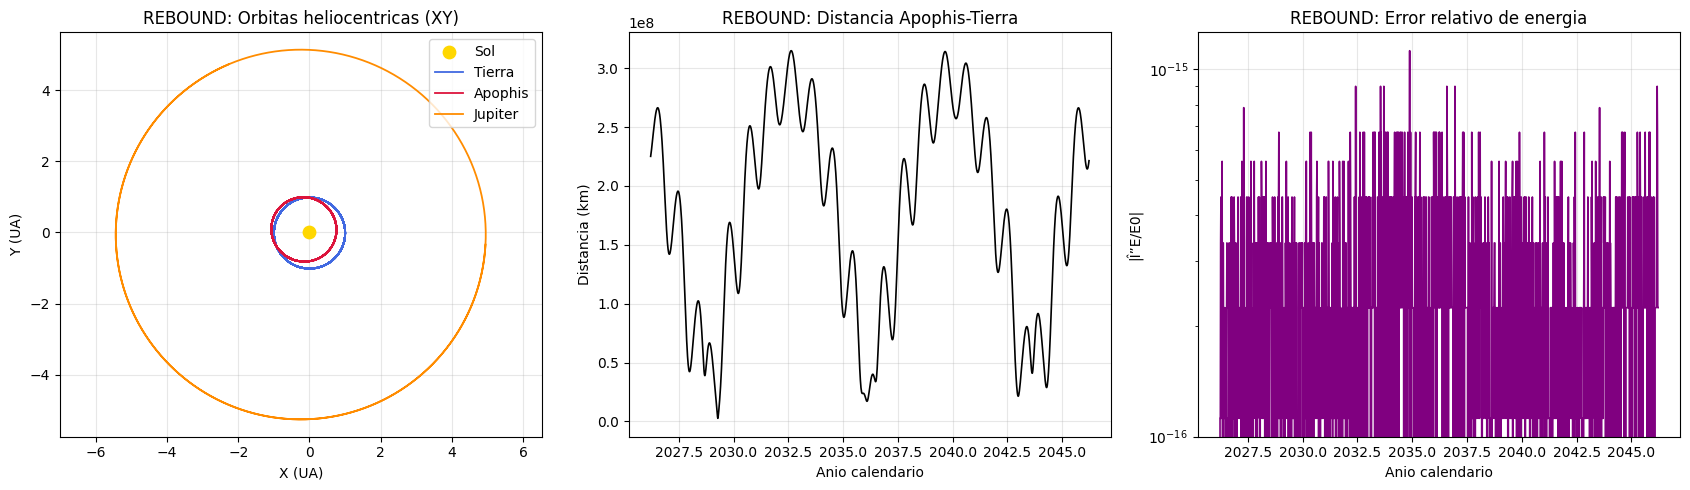

Error relativo maximo de energia (REBOUND): 1.121e-15


In [ ]:
# Comparacion robusta con REBOUND (IAS15) en SI
sim = rb.Simulation()
sim.G = G
sim.integrator = 'ias15'

# Particulas: Sol, Tierra, Apophis, Jupiter
for body in sistema:
    r = body['r']
    v = body['v']
    sim.add(m=body['m'], x=r[0], y=r[1], z=r[2], vx=v[0], vy=v[1], vz=v[2])

# Muestreo cada 5 dias para hacer la simulacion mas rapida
paso_muestreo = 5
t_dias_rb = t_dias[::paso_muestreo]
t_anios_rb = t_dias_rb / 365.25
anios_rb = anio_inicio + t_anios_rb
t_seg_rb = t_dias_rb * 86400.0

rs_rb = np.zeros((len(sistema), len(t_seg_rb), 3))
E_rb = np.zeros(len(t_seg_rb))

for k, t in enumerate(t_seg_rb):
    sim.integrate(float(t))
    E_rb[k] = sim.energy()
    for i, p in enumerate(sim.particles):
        rs_rb[i, k, 0] = p.x
        rs_rb[i, k, 1] = p.y
        rs_rb[i, k, 2] = p.z

# Coordenadas heliocentricas
rs_rb_helio = rs_rb - rs_rb[0:1, :, :]

fig, ax = plt.subplots(1, 3, figsize=(17, 5))

# Orbitas XY en UA
ax[0].scatter(0.0, 0.0, color='gold', s=80, label='Sol', zorder=5)
for idx, nombre, color in zip([1, 2, 3], ['Tierra', 'Apophis', 'Jupiter'], ['royalblue', 'crimson', 'darkorange']):
    ax[0].plot(rs_rb_helio[idx, :, 0] / U_L, rs_rb_helio[idx, :, 1] / U_L, color=color, lw=1.3, label=nombre)
ax[0].set_title('REBOUND: Orbitas heliocentricas (XY)')
ax[0].set_xlabel('X (UA)')
ax[0].set_ylabel('Y (UA)')
ax[0].axis('equal')
ax[0].grid(True, alpha=0.3)
ax[0].legend()

# Distancia Apophis-Tierra
dist_rb_km = np.linalg.norm(rs_rb_helio[2] - rs_rb_helio[1], axis=1) / 1e3
ax[1].plot(anios_rb, dist_rb_km, color='black', lw=1.2)
ax[1].set_title('REBOUND: Distancia Apophis-Tierra')
ax[1].set_xlabel('Anio calendario')
ax[1].set_ylabel('Distancia (km)')
ax[1].grid(True, alpha=0.3)

# Error relativo de energia
errE_rb = np.abs((E_rb - E_rb[0]) / E_rb[0])
ax[2].plot(anios_rb, errE_rb, color='purple', lw=1.2)
ax[2].set_title('REBOUND: Error relativo de energia')
ax[2].set_xlabel('Anio calendario')
ax[2].set_ylabel('|ÃŽâ€E/E0|')
ax[2].set_yscale('log')
ax[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Error relativo maximo de energia (REBOUND): {np.nanmax(errE_rb):.3e}")

In [ ]:
#Simulacion 3D interactiva con Plotly dentro del notebook (usa salida REBOUND)

from IPython.display import HTML, display
import numpy as np
import plotly.graph_objects as go

# Verificacion
if 'rs_rb_helio' not in globals() or 't_dias_rb' not in globals():
    raise RuntimeError('Primero ejecuta la celda 9 (REBOUND) para generar rs_rb_helio y t_dias_rb.')

# Configuracion
nombres = ['Tierra', 'Apophis', 'Jupiter']
indices = [1, 2, 3]
colores = ['royalblue', 'crimson', 'darkorange']

# Posiciones heliocentricas en UA
xyz = rs_rb_helio[indices, :, :] / U_L

# Reducir cantidad de frames para mantener la animacion fluida
stride = max(1, len(t_dias_rb) // 220)
frame_ids = np.arange(0, len(t_dias_rb), stride)

# Figura
fig = go.Figure()

# Sol fijo en el origen
fig.add_trace(go.Scatter3d(
    x=[0.0], y=[0.0], z=[0.0],
    mode='markers',
    marker=dict(size=6, color='gold'),
    name='Sol'
))

# Estado inicial
i0 = int(frame_ids[0])

for k, (nombre, color) in enumerate(zip(nombres, colores)):
    fig.add_trace(go.Scatter3d(
        x=xyz[k, :i0+1, 0],
        y=xyz[k, :i0+1, 1],
        z=xyz[k, :i0+1, 2],
        mode='lines',
        line=dict(color=color, width=4),
        name=f'{nombre} orbita'
    ))

    fig.add_trace(go.Scatter3d(
        x=[xyz[k, i0, 0]],
        y=[xyz[k, i0, 1]],
        z=[xyz[k, i0, 2]],
        mode='markers',
        marker=dict(size=4, color=color),
        name=nombre
    ))

# Frames
frames = []

for i in frame_ids:
    i = int(i)

    frame_data = [
        go.Scatter3d(
            x=[0.0], y=[0.0], z=[0.0],
            mode='markers',
            marker=dict(size=6, color='gold'),
            name='Sol'
        )
    ]

    for k, color in enumerate(colores):
        frame_data.append(go.Scatter3d(
            x=xyz[k, :i+1, 0],
            y=xyz[k, :i+1, 1],
            z=xyz[k, :i+1, 2],
            mode='lines',
            line=dict(color=color, width=4)
        ))

        frame_data.append(go.Scatter3d(
            x=[xyz[k, i, 0]],
            y=[xyz[k, i, 1]],
            z=[xyz[k, i, 2]],
            mode='markers',
            marker=dict(size=4, color=color)
        ))

    frames.append(go.Frame(data=frame_data, name=str(i)))

fig.frames = frames

# Layout
fig.update_layout(
    title='Simulacion orbital heliocentrica 3D (REBOUND + Plotly)',
    scene=dict(
        xaxis_title='X (UA)',
        yaxis_title='Y (UA)',
        zaxis_title='Z (UA)',
        aspectmode='data'
    ),
    template='plotly_white',
    updatemenus=[dict(
        type='buttons',
        showactive=False,
        buttons=[
            dict(
                label='Play',
                method='animate',
                args=[None, dict(frame=dict(duration=45, redraw=True), fromcurrent=True)]
            ),
            dict(
                label='Pause',
                method='animate',
                args=[[None], dict(frame=dict(duration=0, redraw=False), mode='immediate')]
            )
        ]
    )],
    sliders=[dict(
        currentvalue=dict(prefix='Dia: '),
        steps=[
            dict(
                method='animate',
                args=[[str(int(i))],
                      dict(mode='immediate', frame=dict(duration=0, redraw=True))],
                label=f'{t_dias_rb[int(i)]:.0f}'
            ) for i in frame_ids
        ]
    )]
)

# Mostrar en notebook
display(HTML(fig.to_html(include_plotlyjs='cdn', full_html=False)))

In [ ]:
# Acercamiento minimo Apophis-Tierra (2D) y comparacion con 13-04-2029
print('[EDIT TEST] Celda 10 modificada por Python JSON editor')
print('âœ“ PRUEBA DE EDICION EXITOSA: Celda 10 modificada por script Python')
import numpy as np
import matplotlib.pyplot as plt
from astropy.time import Time

required = ['rs_rb_helio', 't_dias_rb', 'fecha_inicio', 'U_L']
for var in required:
    if var not in globals():
        raise RuntimeError(f"Falta '{var}'. Ejecuta primero la celda de REBOUND.")

r_tierra = rs_rb_helio[1]
r_apophis = rs_rb_helio[2]
dr = r_apophis - r_tierra
dist_m = np.linalg.norm(dr, axis=1)
i_min = int(np.argmin(dist_m))
d_min_km = dist_m[i_min] / 1e3

fecha_min = (Time(fecha_inicio) + t_dias_rb[i_min]).to_datetime()
fecha_ref = Time('2029-04-13').to_datetime()
delta_dias = abs((fecha_min - fecha_ref).total_seconds()) / 86400.0

print(f"Fecha de maximo acercamiento (modelo): {fecha_min:%Y-%m-%d %H:%M:%S}")
print(f"Distancia minima Apophis-Tierra: {d_min_km:,.0f} km")
print(f"Diferencia respecto a 2029-04-13: {delta_dias:.2f} dias")

ancho = 250
i0 = max(0, i_min - ancho)
i1 = min(len(t_dias_rb), i_min + ancho + 1)
r_tierra_ua = r_tierra / U_L
r_apophis_ua = r_apophis / U_L

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(r_tierra_ua[i0:i1, 0], r_tierra_ua[i0:i1, 1], color='royalblue', lw=1.8, label='Tierra (ventana local)')
ax.plot(r_apophis_ua[i0:i1, 0], r_apophis_ua[i0:i1, 1], color='crimson', lw=1.8, label='Apophis (ventana local)')
ax.scatter(r_tierra_ua[i_min, 0], r_tierra_ua[i_min, 1], color='royalblue', s=60, marker='o', zorder=5, label='Tierra en minimo')
ax.scatter(r_apophis_ua[i_min, 0], r_apophis_ua[i_min, 1], color='crimson', s=60, marker='o', zorder=5, label='Apophis en minimo')
ax.plot([r_tierra_ua[i_min, 0], r_apophis_ua[i_min, 0]], [r_tierra_ua[i_min, 1], r_apophis_ua[i_min, 1]], color='black', ls='--', lw=1.4, label=f'd_min = {d_min_km:,.0f} km')
ax.set_title('Acercamiento minimo Apophis-Tierra (plano XY, heliocentrico)')
ax.set_xlabel('X (UA)')
ax.set_ylabel('Y (UA)')
ax.axis('equal')
ax.grid(True, alpha=0.3)
ax.legend(loc='best')
plt.show()


In [ ]:
# Nueva animacion 3D con el punto de acercamiento minimo resaltado
from IPython.display import HTML, display
import numpy as np
import plotly.graph_objects as go

required = ['rs_rb_helio', 't_dias_rb', 'U_L']
for var in required:
    if var not in globals():
        raise RuntimeError(f"Falta '{var}'. Ejecuta primero la celda de REBOUND y la celda del minimo.")

if 'i_min' not in globals():
    dist_tmp = np.linalg.norm(rs_rb_helio[2] - rs_rb_helio[1], axis=1)
    i_min = int(np.argmin(dist_tmp))

nombres = ['Tierra', 'Apophis', 'Jupiter']
indices = [1, 2, 3]
colores = ['royalblue', 'crimson', 'darkorange']
xyz = rs_rb_helio[indices, :, :] / U_L

p_tierra_min = xyz[0, i_min, :]
p_apophis_min = xyz[1, i_min, :]

stride = max(1, len(t_dias_rb) // 220)
frame_ids = np.arange(0, len(t_dias_rb), stride)
fig2 = go.Figure()

fig2.add_trace(go.Scatter3d(x=[0.0], y=[0.0], z=[0.0], mode='markers', marker=dict(size=6, color='gold'), name='Sol'))

i0 = int(frame_ids[0])
for k, (nombre, color) in enumerate(zip(nombres, colores)):
    fig2.add_trace(go.Scatter3d(x=xyz[k, :i0+1, 0], y=xyz[k, :i0+1, 1], z=xyz[k, :i0+1, 2], mode='lines', line=dict(color=color, width=4), name=f'{nombre} orbita'))
    fig2.add_trace(go.Scatter3d(x=[xyz[k, i0, 0]], y=[xyz[k, i0, 1]], z=[xyz[k, i0, 2]], mode='markers', marker=dict(size=4, color=color), name=nombre))

fig2.add_trace(go.Scatter3d(x=[p_tierra_min[0]], y=[p_tierra_min[1]], z=[p_tierra_min[2]], mode='markers', marker=dict(size=7, color='deepskyblue', symbol='diamond'), name='Tierra @ minimo'))
fig2.add_trace(go.Scatter3d(x=[p_apophis_min[0]], y=[p_apophis_min[1]], z=[p_apophis_min[2]], mode='markers', marker=dict(size=7, color='red', symbol='diamond'), name='Apophis @ minimo'))
fig2.add_trace(go.Scatter3d(x=[p_tierra_min[0], p_apophis_min[0]], y=[p_tierra_min[1], p_apophis_min[1]], z=[p_tierra_min[2], p_apophis_min[2]], mode='lines', line=dict(color='black', width=4, dash='dash'), name='Segmento d_min'))

frames = []
for i in frame_ids:
    i = int(i)
    frame_data = [go.Scatter3d(x=[0.0], y=[0.0], z=[0.0], mode='markers', marker=dict(size=6, color='gold'), name='Sol')]
    for k, color in enumerate(colores):
        frame_data.append(go.Scatter3d(x=xyz[k, :i+1, 0], y=xyz[k, :i+1, 1], z=xyz[k, :i+1, 2], mode='lines', line=dict(color=color, width=4)))
        frame_data.append(go.Scatter3d(x=[xyz[k, i, 0]], y=[xyz[k, i, 1]], z=[xyz[k, i, 2]], mode='markers', marker=dict(size=4, color=color)))
    frame_data.append(go.Scatter3d(x=[p_tierra_min[0]], y=[p_tierra_min[1]], z=[p_tierra_min[2]], mode='markers', marker=dict(size=7, color='deepskyblue', symbol='diamond')))
    frame_data.append(go.Scatter3d(x=[p_apophis_min[0]], y=[p_apophis_min[1]], z=[p_apophis_min[2]], mode='markers', marker=dict(size=7, color='red', symbol='diamond')))
    frame_data.append(go.Scatter3d(x=[p_tierra_min[0], p_apophis_min[0]], y=[p_tierra_min[1], p_apophis_min[1]], z=[p_tierra_min[2], p_apophis_min[2]], mode='lines', line=dict(color='black', width=4, dash='dash')))
    frames.append(go.Frame(data=frame_data, name=str(i)))

fig2.frames = frames
fig2.update_layout(
    title='Simulacion 3D con punto de acercamiento minimo Apophis-Tierra',
    scene=dict(xaxis_title='X (UA)', yaxis_title='Y (UA)', zaxis_title='Z (UA)', aspectmode='data'),
    template='plotly_white',
    updatemenus=[dict(type='buttons', showactive=False, buttons=[
        dict(label='Play', method='animate', args=[None, dict(frame=dict(duration=45, redraw=True), fromcurrent=True)]),
        dict(label='Pause', method='animate', args=[[None], dict(frame=dict(duration=0, redraw=False), mode='immediate')])
    ])],
    sliders=[dict(currentvalue=dict(prefix='Dia: '), steps=[
        dict(method='animate', args=[[str(int(i))], dict(mode='immediate', frame=dict(duration=0, redraw=True))], label=f'{t_dias_rb[int(i)]:.0f}') for i in frame_ids
    ])]
)
display(HTML(fig2.to_html(include_plotlyjs='cdn', full_html=False)))


In [ ]:
import plotly.graph_objects as go
import numpy as np
from IPython.display import HTML, display

# Validar variables necesarias
required = ['rs_rb_helio', 't_dias_rb', 'idx_min', 'fecha_min', 'U_L']
for var in required:
    if var not in globals():
        raise RuntimeError(f"Variable '{var}' no encontrada. Ejecuta celdas anteriores.")

# Extraer datos de Tierra y Apophis
r_tierra = rs_rb_helio[1]  # Tierra
r_apophis = rs_rb_helio[2]  # Apophis

# Convertir a UA
r_tierra_ua = r_tierra / U_L
r_apophis_ua = r_apophis / U_L

# Ventana de tiempo alrededor del encuentro (Â±100 pasos)
i_min = idx_min
i_start = max(0, i_min - 100)
i_end = min(len(t_dias_rb), i_min + 100)

t_window = t_dias_rb[i_start:i_end+1]
r_tierra_window = r_tierra_ua[i_start:i_end+1]
r_apophis_window = r_apophis_ua[i_start:i_end+1]

print(f"âœ“ Ventana de animaciÃ³n: {len(t_window)} frames")

# Crear frames
frames = []
for step in range(len(t_window)):
    frame_data = []
    
    # Ã“rbitas completas de fondo
    frame_data.append(go.Scatter3d(
        x=r_tierra_ua[:, 0], y=r_tierra_ua[:, 1], z=r_tierra_ua[:, 2],
        mode='lines',
        name='Ã“rbita Tierra',
        line=dict(color='lightblue', width=1),
        opacity=0.2,
        showlegend=False
    ))
    
    frame_data.append(go.Scatter3d(
        x=r_apophis_ua[:, 0], y=r_apophis_ua[:, 1], z=r_apophis_ua[:, 2],
        mode='lines',
        name='Ã“rbita Apophis',
        line=dict(color='lightyellow', width=1),
        opacity=0.2,
        showlegend=False
    ))
    
    # Trayectorias pasadas
    if step > 0:
        frame_data.append(go.Scatter3d(
            x=r_tierra_window[:step, 0], y=r_tierra_window[:step, 1], z=r_tierra_window[:step, 2],
            mode='lines',
            name='Trayect. Tierra',
            line=dict(color='blue', width=2),
            showlegend=False
        ))
        frame_data.append(go.Scatter3d(
            x=r_apophis_window[:step, 0], y=r_apophis_window[:step, 1], z=r_apophis_window[:step, 2],
            mode='lines',
            name='Trayect. Apophis',
            line=dict(color='red', width=2),
            showlegend=False
        ))
    
    # Posiciones actuales
    frame_data.append(go.Scatter3d(
        x=[r_tierra_window[step, 0]], y=[r_tierra_window[step, 1]], z=[r_tierra_window[step, 2]],
        mode='markers+text',
        name='Tierra',
        marker=dict(size=10, color='blue'),
        text=['Tierra'],
        textposition='top center',
        showlegend=False
    ))
    
    frame_data.append(go.Scatter3d(
        x=[r_apophis_window[step, 0]], y=[r_apophis_window[step, 1]], z=[r_apophis_window[step, 2]],
        mode='markers+text',
        name='Apophis',
        marker=dict(size=10, color='red'),
        text=['Apophis'],
        textposition='top center',
        showlegend=False
    ))
    
    # LÃ­nea de distancia entre ellos
    dist_step = np.linalg.norm(r_tierra_window[step] - r_apophis_window[step])
    marker_color = 'green' if step == len(t_window) // 2 else 'yellow'
    
    frame_data.append(go.Scatter3d(
        x=[r_tierra_window[step, 0], r_apophis_window[step, 0]],
        y=[r_tierra_window[step, 1], r_apophis_window[step, 1]],
        z=[r_tierra_window[step, 2], r_apophis_window[step, 2]],
        mode='lines+markers',
        name='Distancia',
        line=dict(color=marker_color, width=3),
        marker=dict(size=6, color=marker_color),
        showlegend=False
    ))
    
    frames.append(go.Frame(data=frame_data, name=f"d={dist_step:.4f} UA"))

# Crear figura con primer frame
fig = go.Figure(data=frames[0].data, frames=frames)

fig.update_layout(
    updatemenus=[{
        'type': 'buttons',
        'showactive': False,
        'buttons': [
            {'label': 'â–¶ Reproducir', 'method': 'animate',
             'args': [None, {'frame': {'duration': 80, 'redraw': True},
                            'fromcurrent': True, 'transition': {'duration': 20}}]},
            {'label': 'â¸ Pausar', 'method': 'animate',
             'args': [[None], {'frame': {'duration': 0, 'redraw': False},
                              'mode': 'immediate'}]}
        ],
        'x': 0.05, 'y': 0.05
    }],
    title="AnimaciÃ³n 3D: Encuentro Tierra-Apophis (Abril 2029)",
    scene=dict(
        xaxis_title='X (UA)',
        yaxis_title='Y (UA)',
        zaxis_title='Z (UA)',
        aspectmode='data'
    ),
    height=700
)

# InformaciÃ³n
dist_min_ua = np.linalg.norm(r_tierra_ua[i_min] - r_apophis_ua[i_min])
print(f"âœ“ AnimaciÃ³n: {len(frames)} frames")
print(f"âœ“ Distancia mÃ­nima: {dist_min_ua:.6f} UA = {dist_min_ua * 1.496e8:.0f} km")
print(f"âœ“ Fecha encuentro: {fecha_min}")

display(HTML(fig.to_html(include_plotlyjs='cdn', full_html=False)))
